<a href="https://colab.research.google.com/github/SebastianPerezCalle/SENALES-Y-SISTEMAS-2025-1/blob/main/Talleres/Ejercicio_Parcial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Solución ejercicio parcial##
*Sebastián Pérez Calle*

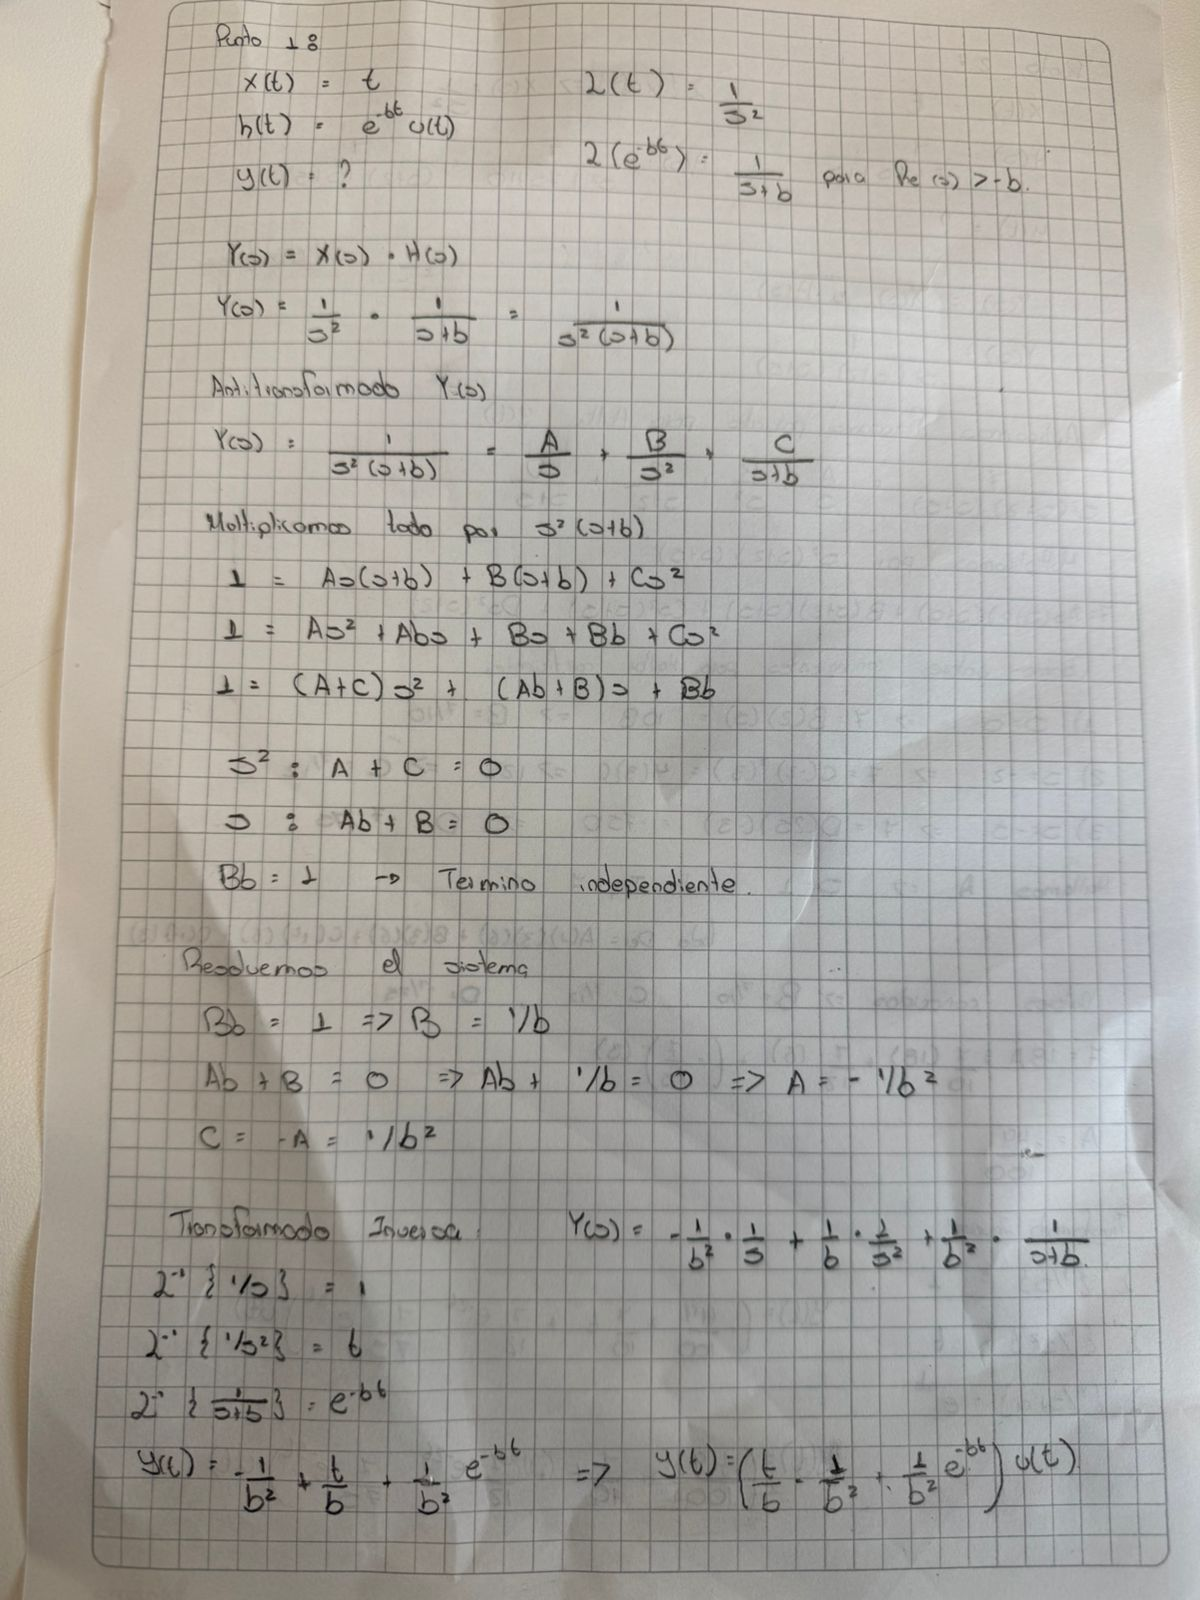

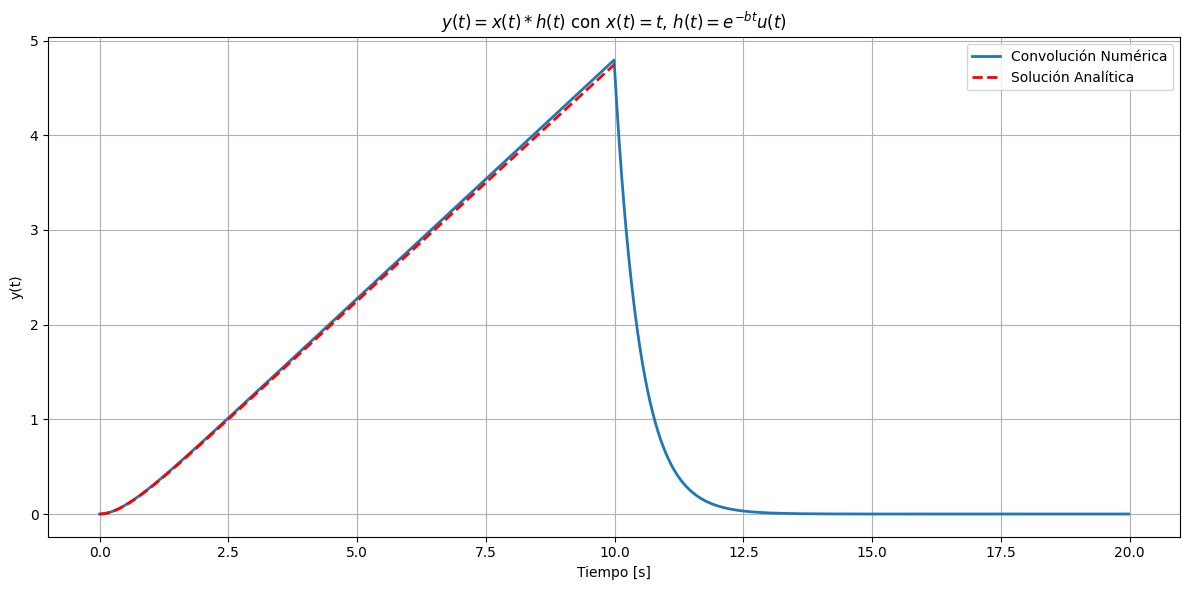

In [1]:
#@title Convolución de x(t) = t con h(t) = e^{-bt}u(t)
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# Parámetros
b = 2.0  # Puedes cambiar el valor de b
Tmax = 10         # Tiempo máximo
dt = 0.01         # Paso de tiempo
t = np.arange(0, Tmax, dt)  # Vector de tiempo desde 0 hasta Tmax

# Definimos las señales
x = t                      # x(t) = t
h = np.exp(-b * t)         # h(t) = e^{-bt} * u(t), ya que t >= 0

# Convolución numérica (discreta)
y_num = convolve(x, h) * dt         # Se multiplica por dt para simular la integral
t_conv = np.arange(0, 2*Tmax - dt, dt)  # Tiempo resultante de la convolución

# Solución analítica de y(t)
y_analitica = (t / b) - (1 / b**2) + (1 / b**2) * np.exp(-b * t)

# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(t_conv, y_num, label='Convolución Numérica', linewidth=2)
plt.plot(t, y_analitica, 'r--', label='Solución Analítica', linewidth=2)
plt.title(r'$y(t) = x(t) * h(t)$ con $x(t) = t$, $h(t) = e^{-bt}u(t)$')
plt.xlabel('Tiempo [s]')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


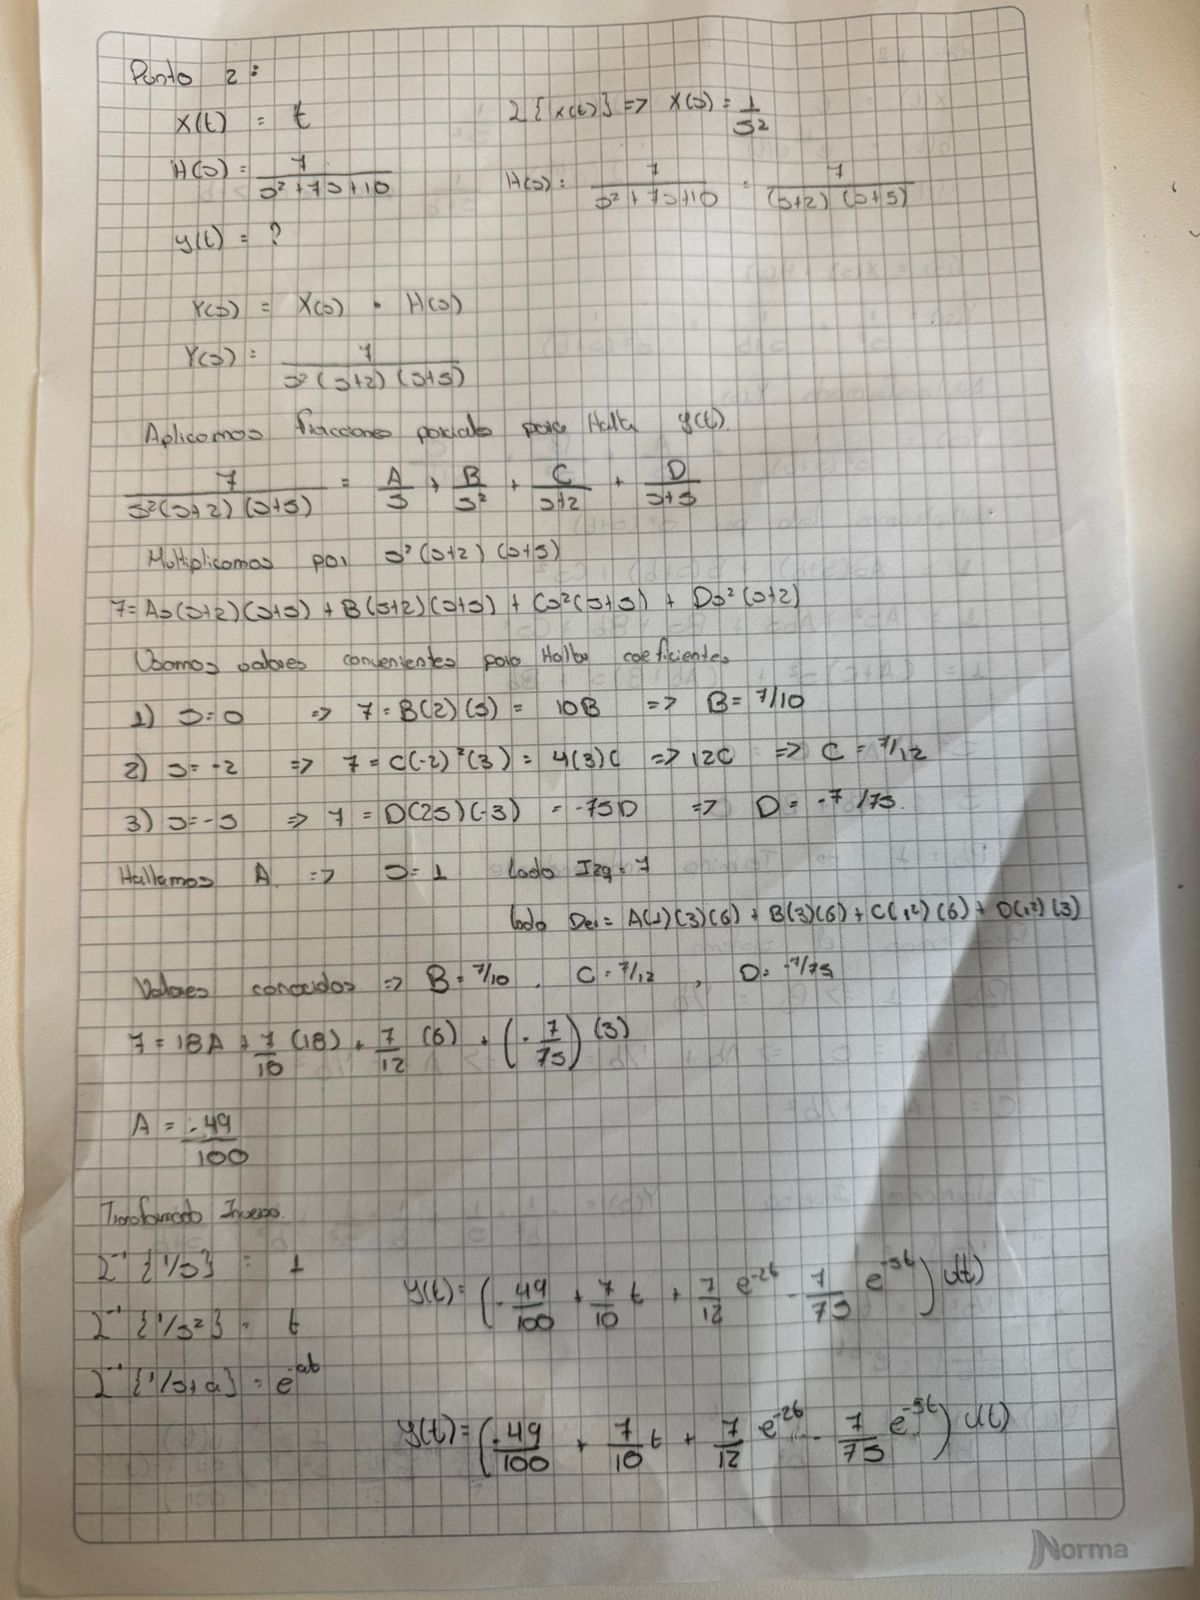

Y(s) =


7/(s**2*(s**2 + 7*s + 10))


Y(s) en fracciones parciales:


-7/(75*(s + 5)) + 7/(12*(s + 2)) - 49/(100*s) + 7/(10*s**2)


y(t) =


7*t/10 - 49/100 + 7*exp(-2*t)/12 - 7*exp(-5*t)/75

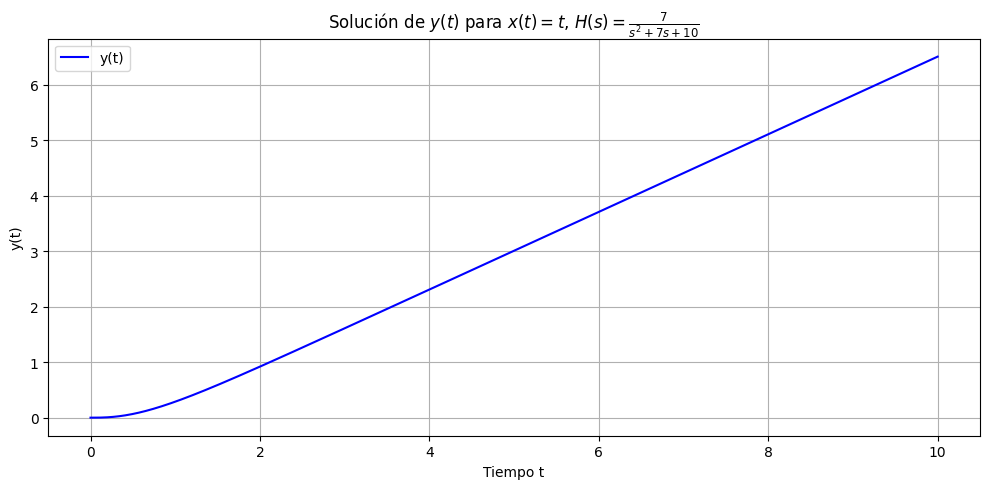

In [2]:
#@title y(t) para x(t) = t y H(s) = 7/(s^2 + 7s + 10) vía Laplace
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir variables simbólicas
s, t = sp.symbols('s t', real=True, positive=True)

# Transformada de x(t) = t → X(s) = 1/s²
X_s = 1 / s**2

# Función de transferencia H(s)
H_s = 7 / (s**2 + 7*s + 10)

# Y(s) = X(s) * H(s)
Y_s = sp.simplify(X_s * H_s)

# Mostrar Y(s)
print("Y(s) =")
display(Y_s)

# Descomponer en fracciones parciales
Y_s_partes = sp.apart(Y_s, s)
print("\nY(s) en fracciones parciales:")
display(Y_s_partes)

# Transformada inversa para obtener y(t)
y_t = sp.inverse_laplace_transform(Y_s, s, t)
print("\ny(t) =")
display(y_t)

# Convertir y(t) a función evaluable
y_t_func = sp.lambdify(t, y_t, 'numpy')

# Evaluar para graficar
tt = np.linspace(0, 10, 1000)
yy = y_t_func(tt)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(tt, yy, label='y(t)', color='blue')
plt.title(r'Solución de $y(t)$ para $x(t)=t$, $H(s)=\frac{7}{s^2 + 7s + 10}$')
plt.xlabel('Tiempo t')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
